In [1]:
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage
import statsmodels.api as sm
import rasterio
import PIL.Image

In [2]:
DIRECTORY = pathlib.Path("~/storage/data/oaec-found-gully").expanduser()

In [3]:
PIL.Image.MAX_IMAGE_PIXELS = None  # I know my images are large; they're not DoS attacks...

In [4]:
names = {
    "pepperwood": "Big Pepperwood Creek",
    "dutch": "Dutch Bill Creek",
    "flat": "Flat Ridge Creek Buckeye",
    "kolmer": "Kolmer Gulch",
    "drylow": "Lower Dry Creek Lower",
    "dry": "Lower Dry Creek",
    "salmon": "Lower Salmon Creek",
    "tombs": "Tombs Creek",
    "sulphur": "Upper Big Sulphur Creek",
}

In [5]:
truth = []
metrics = {
    "min15": [],
    "max15": [],
    "low15": [],
    "highlow15": [],
    "min5": [],
    "max5": [],
    "low5": [],
    "highlow5": [],
    "mindisk": [],
}

for name in names:
    print(name)
    with PIL.Image.open(DIRECTORY / "hand-labeled" / f"{names[name]}-mask.png") as file:
        tmp = np.asarray(file)
        assert tmp[:, :, 1].min() == 0
        assert tmp[:, :, 1].max() == 255
        mask = tmp[:, :, 1] < 128
        del tmp

    with PIL.Image.open(DIRECTORY / "hand-labeled" / f"{names[name]}-gully.png") as file:
        tmp = np.asarray(file)
        assert tmp[:, :, 1].min() == 0
        assert tmp[:, :, 1].max() == 255
        gully = tmp[:, :, 1] > 128
        del tmp

    for metric in metrics:
        with rasterio.open(DIRECTORY / "derived" / metric / f"{names[name]}-{metric}.tif") as file:
            data = file.read(1)
        np.logical_and(mask, ~np.isnan(data), out=mask)  # assumes they all have NaNs in the same places
        metrics[metric].append(data[mask])
        del data

    truth.append(gully[mask])
    del mask
    del gully

pepperwood
dutch
flat
kolmer
drylow
dry
salmon
tombs
sulphur


In [6]:
slices = []
start = 0
for name, array in zip(names, truth):
    stop = start + len(array)
    slices.append(slice(start, stop))
    start = stop

alltruth = np.concatenate(truth)
allmetrics = {metric: np.concatenate(arrays) for metric, arrays in metrics.items()}

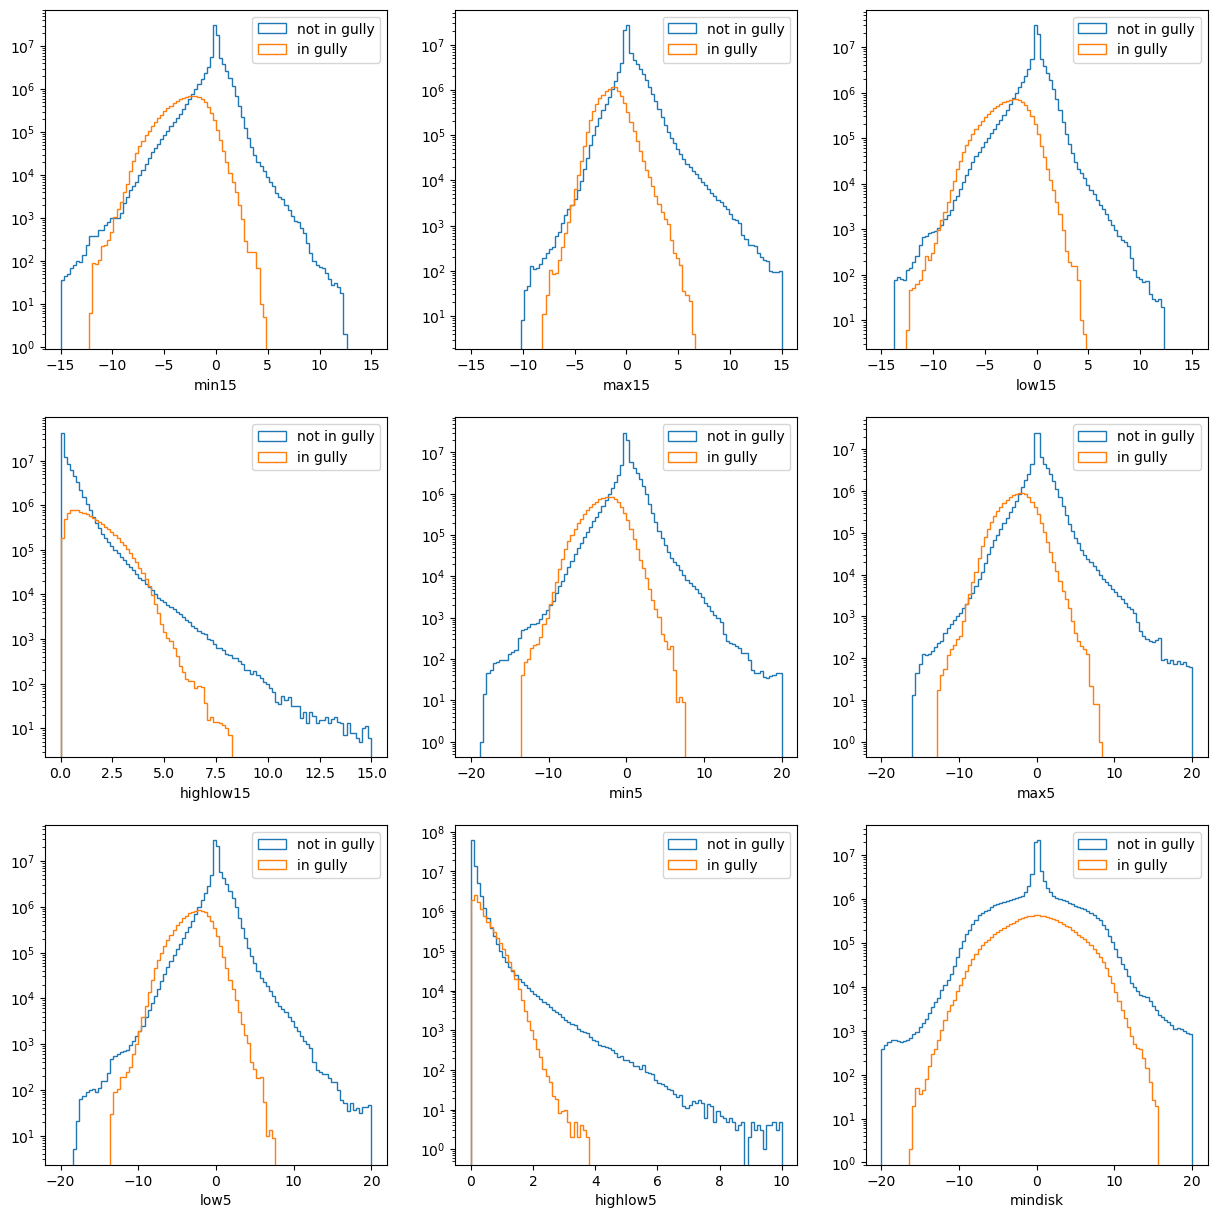

In [7]:
fig, axs = plt.subplots(3, 3, figsize=(15, 15))

ranges = {
    "min15": (-15, 15),
    "max15": (-15, 15),
    "low15": (-15, 15),
    "highlow15": (0, 15),
    "min5": (-20, 20),
    "max5": (-20, 20),
    "low5": (-20, 20),
    "highlow5": (0, 10),
    "mindisk": (-20, 20),
}

for ax, metric in zip(axs.flatten(), metrics):
    ax.hist(allmetrics[metric][~alltruth], bins=100, range=ranges[metric], histtype="step", label="not in gully")
    ax.hist(allmetrics[metric][alltruth], bins=100, range=ranges[metric], histtype="step", label="in gully")

    ax.legend()
    
    ax.set_yscale("log")
    ax.set_xlabel(metric)

None

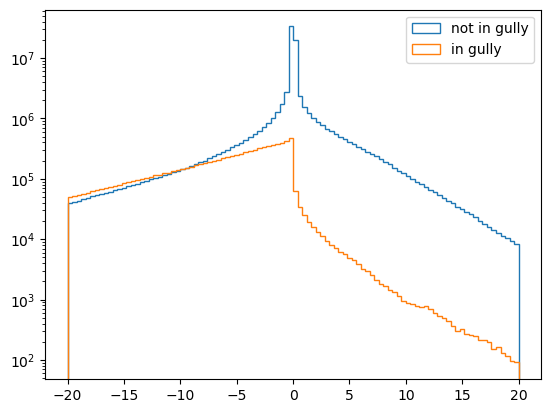

In [8]:
fig, ax = plt.subplots()

ridge_veto = allmetrics["min15"] * abs(allmetrics["mindisk"])

ax.hist(ridge_veto[~alltruth], bins=100, range=(-20, 20), histtype="step", label="not in gully")
ax.hist(ridge_veto[alltruth], bins=100, range=(-20, 20), histtype="step", label="in gully")

ax.legend()

ax.set_yscale("log")

None

In [9]:
del truth
del metrics

features = [
    "min15",
    "low15 - min15",
    "high15 - low15",
    "min5 - min15",
    "high5 - low5",
    "low15 * (high15 - low15)",
    "min15 * mindisk**2",
]

X = np.stack([
    allmetrics["min15"],
    allmetrics["low15"] - allmetrics["min15"],
    allmetrics["highlow15"],
    allmetrics["min5"] - allmetrics["min15"],
    allmetrics["highlow5"],
    allmetrics["low15"] * allmetrics["highlow15"],
    allmetrics["min15"] * allmetrics["mindisk"]**2,
]).T
Y = alltruth

del allmetrics
del alltruth

In [10]:
fit = sm.Logit(Y, sm.add_constant(X)).fit()

Optimization terminated successfully.
         Current function value: 0.169528
         Iterations 8


In [11]:
# fit.summary()

In [12]:
for feature, parameter in zip(["(intercept)"] + features, fit.params):
    print(f"{feature:25s} {parameter:9.6f}")

(intercept)               -4.312588
min15                     -2.124413
low15 - min15              0.422340
high15 - low15             0.075935
min5 - min15               1.422081
high5 - low5               0.445558
low15 * (high15 - low15)   0.337618
min15 * mindisk**2         0.008673


In [13]:
cov_mat = fit.cov_params()
stdev = np.sqrt(np.diag(cov_mat))
corr_mat = cov_mat / np.outer(stdev, stdev)

pd.DataFrame(corr_mat, index=["(intercept)"] + features, columns=["(intercept)"] + features).style.background_gradient(
    cmap="coolwarm", vmin=-1, vmax=1
)

,(intercept),min15,low15 - min15,high15 - low15,min5 - min15,high5 - low5,low15 * (high15 - low15),min15 * mindisk**2
(intercept),1.000000,0.533201,-0.009390,-0.167923,-0.135310,-0.074033,-0.487556,-0.096266
min15,0.533201,1.000000,0.276650,0.450439,-0.528400,-0.279907,-0.358511,-0.389569
low15 - min15,-0.009390,0.276650,1.000000,0.249792,-0.183086,-0.405080,0.004882,-0.043565
high15 - low15,-0.167923,0.450439,0.249792,1.000000,-0.706558,-0.629980,0.499346,-0.133323
min5 - min15,-0.135310,-0.528400,-0.183086,-0.706558,1.000000,0.287160,-0.327752,0.161694
high5 - low5,-0.074033,-0.279907,-0.405080,-0.629980,0.287160,1.000000,-0.099734,0.063084
low15 * (high15 - low15),-0.487556,-0.358511,0.004882,0.499346,-0.327752,-0.099734,1.000000,0.000410
min15 * mindisk**2,-0.096266,-0.389569,-0.043565,-0.133323,0.161694,0.063084,0.000410,1.000000


In [14]:
test_samples = np.stack([np.ones(1000)] + [np.random.uniform(-10, 10, 1000) for _ in features]).T

predictions = fit.predict(test_samples)

def logistic(x):
    return 1/(1 + np.exp(-x))

for test_sample, prediction in zip(test_samples, predictions):
    assert abs(logistic(fit.params @ test_sample.T) - prediction) < 1e-15

In [15]:
fit.params.tolist()

[-4.312588352365304,
 -2.124413197778558,
 0.4223402951899627,
 0.07593547918695243,
 1.4220807750184314,
 0.4455583284143665,
 0.33761829962995676,
 0.008672880872815985]

In [17]:
for test_sample, prediction in zip(test_samples, predictions):
    assert abs(
        logistic(
              -4.312588352365304
            + -2.124413197778558    * test_sample[1]  # min15
            +  0.4223402951899627   * test_sample[2]  # low15 - min15
            +  0.07593547918695243  * test_sample[3]  # high15 - low15
            +  1.4220807750184314   * test_sample[4]  # min5 - min15
            +  0.4455583284143665   * test_sample[5]  # high5 - low5
            +  0.33761829962995676  * test_sample[6]  # low15 * (high15 - low15)
            +  0.008672880872815985 * test_sample[7]  # min15 * mindisk**2
        ) - prediction
    ) < 1e-15

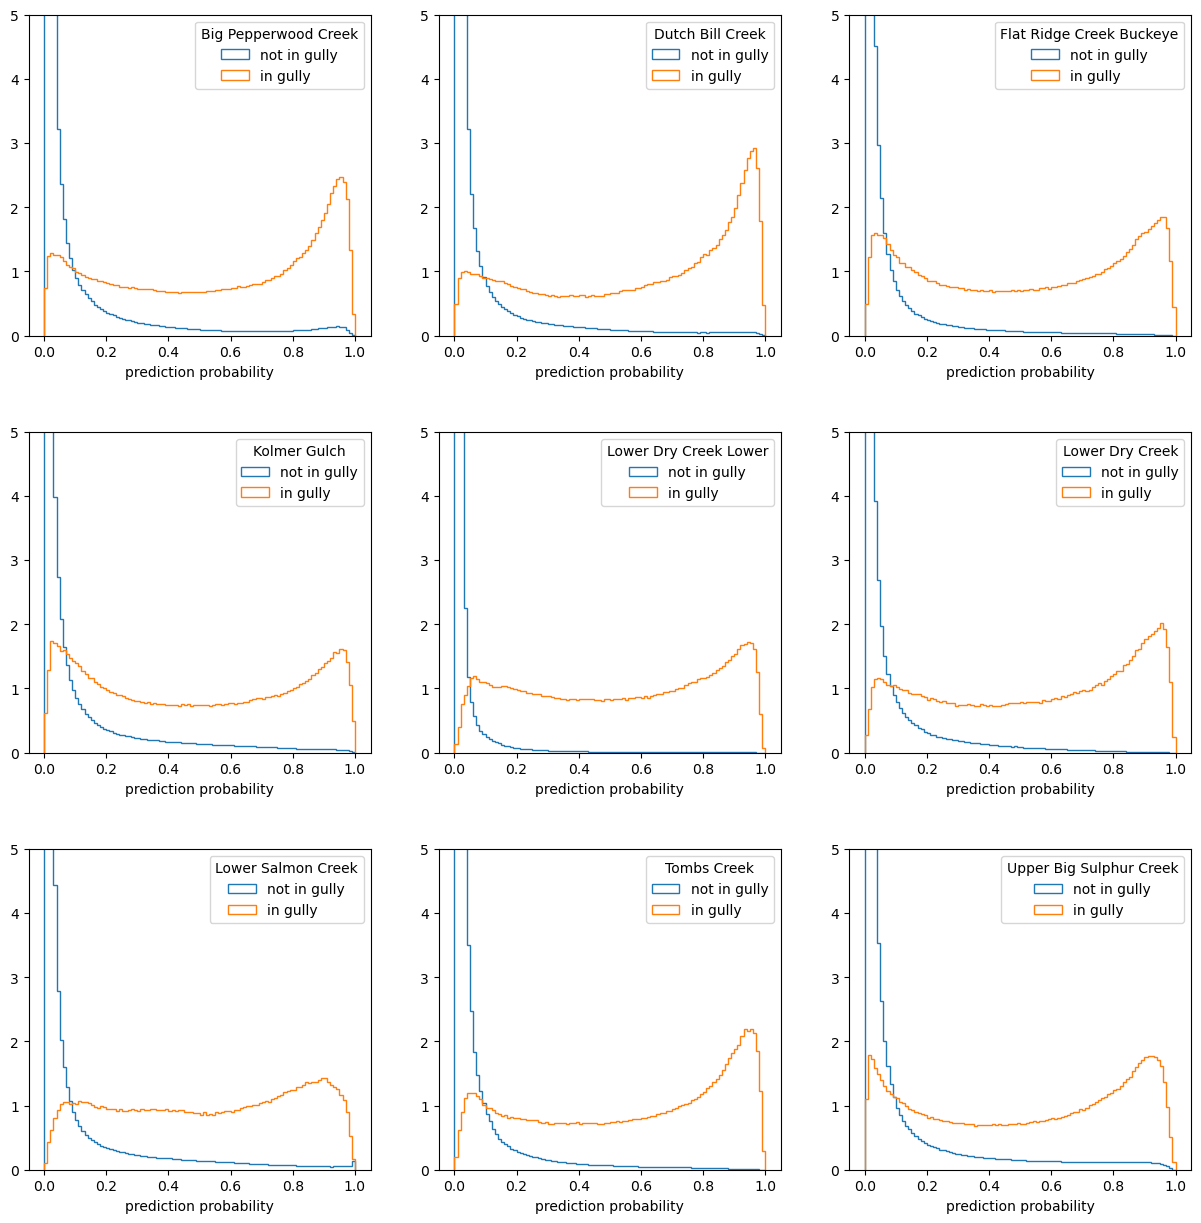

In [18]:
fig, axs = plt.subplots(3, 3, figsize=(15, 15))

for ax, name, slc in zip(axs.flatten(), names, slices):
    ax.hist(fit.predict(sm.add_constant(X)[slc][~Y[slc]]), bins=100, range=(0, 1), density=True, histtype="step", label="not in gully")
    ax.hist(fit.predict(sm.add_constant(X)[slc][Y[slc]]), bins=100, range=(0, 1), density=True, histtype="step", label="in gully")

    ax.legend(loc="upper right", title=names[name])

    ax.set_ylim(0, 5)
    ax.set_xlabel("prediction probability")

plt.subplots_adjust(hspace=0.3)

None

In [19]:
name = "dutch"

with PIL.Image.open(DIRECTORY / "hand-labeled" / f"{names[name]}-mask.png") as file:
    mask = np.asarray(file)[:, :, 1] < 128

with PIL.Image.open(DIRECTORY / "hand-labeled" / f"{names[name]}-gully.png") as file:
    gully = (np.asarray(file)[:, :, 1] > 128).astype(np.float32)

gully[~mask] = np.nan

metrics = {
    "min15": None,
    "max15": None,
    "low15": None,
    "highlow15": None,
    "min5": None,
    "max5": None,
    "low5": None,
    "highlow5": None,
    "mindisk": None,
}
for metric in metrics:
    with rasterio.open(DIRECTORY / "derived" / metric / f"{names[name]}-{metric}.tif") as file:
        data = file.read(1)
    np.logical_and(mask, ~np.isnan(data), out=mask)  # assumes they all have NaNs in the same places
    metrics[metric]= data

In [20]:
X_test = np.stack([
    metrics["min15"],
    metrics["low15"] - metrics["min15"],
    metrics["highlow15"],
    metrics["min5"] - metrics["min15"],
    metrics["highlow5"],
    metrics["low15"] * metrics["highlow15"],
    metrics["min15"] * metrics["mindisk"]**2,
]).transpose(1, 2, 0)

assert not np.isnan(X_test[mask]).any()
X_test[np.isnan(X_test)] = 0

In [21]:
del metrics

In [22]:
def logistic(x):
    return 1/(1 + np.exp(-x))

probability = logistic(
    -4.312588352365304
    + -2.124413197778558    * X_test[:, :, 0]  # min15
    +  0.4223402951899627   * X_test[:, :, 1]  # low15 - min15
    +  0.07593547918695243  * X_test[:, :, 2]  # high15 - low15
    +  1.4220807750184314   * X_test[:, :, 3]  # min5 - min15
    +  0.4455583284143665   * X_test[:, :, 4]  # high5 - low5
    +  0.33761829962995676  * X_test[:, :, 5]  # low15 * (high15 - low15)
    +  0.008672880872815985 * X_test[:, :, 6]  # min15 * mindisk**2
)

In [ ]:
# probability[~mask] = np.nan

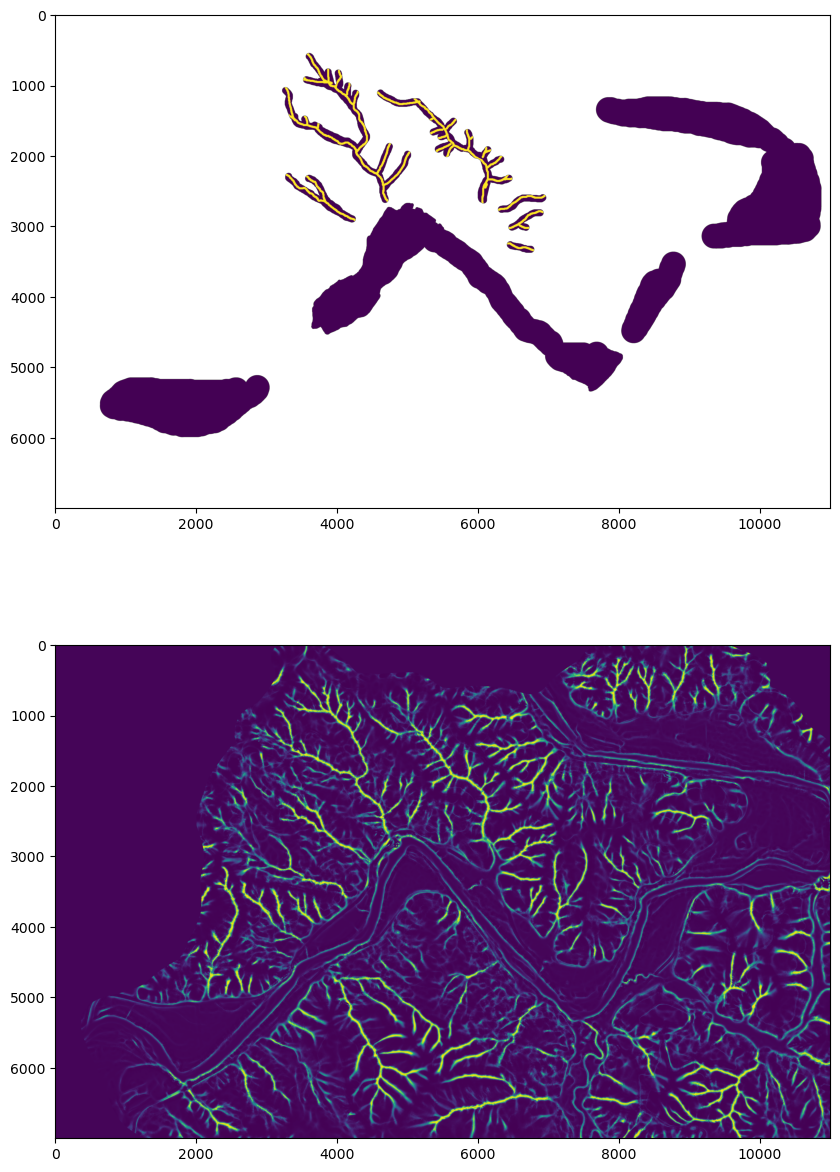

In [23]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 15))

ax1.imshow(gully[1000:8000, 0:11000])
ax2.imshow(probability[1000:8000, 0:11000])

None

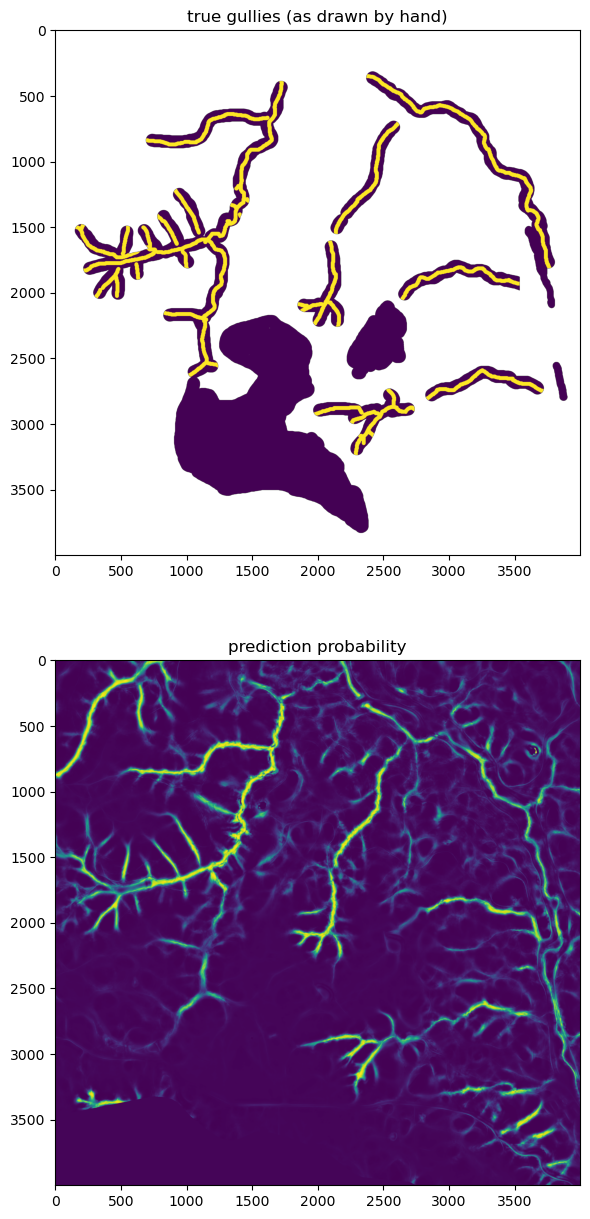

In [24]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 15))

ax1.imshow(gully[15000:19000, 14000:18000])
ax2.imshow(probability[15000:19000, 14000:18000])

ax1.set_title("true gullies (as drawn by hand)")
ax2.set_title("prediction probability")

None